In [29]:
import csv
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import pretty_midi
import os
from pathlib import Path

In [30]:
df = pd.read_csv("jsb_chorales/train/chorale_000.csv")

print("First few chords of chorale 000:")
print(df.head())

# 4 notes playing together 

First few chords of chorale 000:
   note0  note1  note2  note3
0     74     70     65     58
1     74     70     65     58
2     74     70     65     58
3     74     70     65     58
4     75     70     58     55


In [31]:
note_cols = ["note0", "note1", "note2", "note3"]
df_notes = df[note_cols].copy()

NOTE_NAMES = ['C', 'C#', 'D', 'D#', 'E', 'F',
              'F#', 'G', 'G#', 'A', 'A#', 'B']

def midi_to_note_name(midi_num):
    midi_num = int(midi_num)
    octave = (midi_num // 12) - 1
    note = NOTE_NAMES[midi_num % 12]
    return f"{note}{octave}"

df_named = df_notes.map(midi_to_note_name)
print("First few note rows:")
print(df_named.head())

First few note rows:
  note0 note1 note2 note3
0    D5   A#4    F4   A#3
1    D5   A#4    F4   A#3
2    D5   A#4    F4   A#3
3    D5   A#4    F4   A#3
4   D#5   A#4   A#3    G3


In [32]:
df_named["chord_names"] = df_named.apply(
    lambda row: list(row.values),
    axis=1
)

print("\nFirst few chords:")
print(df_named[["chord_names"]].head(50))


First few chords:
            chord_names
0    [D5, A#4, F4, A#3]
1    [D5, A#4, F4, A#3]
2    [D5, A#4, F4, A#3]
3    [D5, A#4, F4, A#3]
4   [D#5, A#4, A#3, G3]
5   [D#5, A#4, A#3, G3]
6    [D#5, A#4, C4, G3]
7    [D#5, A#4, C4, G3]
8      [F5, A4, D4, D3]
9      [F5, A4, D4, D3]
10     [F5, A4, D4, D3]
11     [F5, A4, D4, D3]
12    [F5, A#4, D4, G3]
13    [F5, A#4, D4, G3]
14     [F5, A4, D4, G3]
15     [F5, A4, D4, G3]
16   [D#5, G4, D#4, C3]
17   [D#5, G4, D#4, C3]
18   [D#5, A4, D#4, C3]
19   [D#5, A4, D#4, C3]
20   [D5, A#4, F4, A#2]
21   [D5, A#4, F4, A#2]
22   [D5, A#4, F4, A#2]
23   [D5, A#4, F4, A#2]
24     [C5, A4, F4, F3]
25     [C5, A4, F4, F3]
26     [C5, A4, F4, F3]
27     [C5, A4, F4, F3]
28     [C5, A4, F4, F3]
29     [C5, A4, F4, F3]
30     [C5, A4, F4, F3]
31     [C5, A4, F4, F3]
32   [D5, A#4, F4, A#2]
33   [D5, A#4, F4, A#2]
34   [D5, A#4, F4, A#2]
35   [D5, A#4, F4, A#2]
36   [D#5, A4, D#4, C3]
37   [D#5, A4, D#4, C3]
38   [D#5, G4, D#4, C3]
39   [D#5, G4, D#4, C

In [33]:
import math
import re
import pandas as pd

KK_MAJOR = [6.35, 2.23, 3.48, 2.33, 4.38, 4.09,
            2.52, 5.19, 2.39, 3.66, 2.29, 2.88]
KK_MINOR = [6.33, 2.68, 3.52, 5.38, 2.60, 3.53,
            2.54, 4.75, 3.98, 2.69, 3.34, 3.17]

PC_NAMES_FLAT = ['C', 'Db', 'D', 'Eb', 'E', 'F',
                 'F#', 'G', 'Ab', 'A', 'Bb', 'B']

NOTE_TO_PC = {
    'C': 0, 'B#': 0,
    'C#': 1, 'Db': 1, 'DB': 1,
    'D': 2,
    'D#': 3, 'Eb': 3, 'EB': 3,
    'E': 4, 'Fb': 4, 'FB': 4,
    'F': 5, 'E#': 5,
    'F#': 6, 'Gb': 6, 'GB': 6,
    'G': 7,
    'G#': 8, 'Ab': 8, 'AB': 8,
    'A': 9,
    'A#': 10, 'Bb': 10, 'BB': 10,
    'B': 11, 'Cb': 11, 'CB': 11,
}

def note_name_to_pc(note_str):
    name = re.sub(r'\d+$', '', str(note_str).strip())
    if name in NOTE_TO_PC:
        return NOTE_TO_PC[name]
    for key, value in NOTE_TO_PC.items():
        if key.upper() == name.upper():
            return value
    raise ValueError(f"Unknown note name: {note_str}")

def midi_to_pc(midi_num):
    return int(midi_num) % 12

def convolute_distribution(pc_distribution, weight_type='major'):
    tone_weights = KK_MAJOR if weight_type == 'major' else KK_MINOR
    solution = [0.0] * 12
    for i in range(12):
        for j in range(12):
            solution[i] += tone_weights[(j - i) % 12] * pc_distribution[j]
    return solution

def build_pc_vector_from_midi(df_notes):
    counts = [0.0] * 12
    for _, row in df_notes.iterrows():
        seen_pcs = set()
        for val in row:
            if pd.notna(val):
                pc = midi_to_pc(int(val))
                seen_pcs.add(pc)
        for pc in seen_pcs:
            counts[pc] += 0.5  # quarterLength = 0.5
    return counts

def build_pc_vector_from_chords(chord_list):
    counts = [0.0] * 12
    for chord in chord_list:
        seen_pcs = set()
        for note in chord:
            pc = note_name_to_pc(note)
            seen_pcs.add(pc)
        for pc in seen_pcs:
            counts[pc] += 1.0
    return counts

def find_key_music21_exact(pc_distribution, top_n=5):
    major_scores = convolute_distribution(pc_distribution, 'major')
    minor_scores = convolute_distribution(pc_distribution, 'minor')

    scores = []
    for i in range(12):
        scores.append((major_scores[i], f"{PC_NAMES_FLAT[i]} major"))
        scores.append((minor_scores[i], f"{PC_NAMES_FLAT[i]} minor"))

    scores.sort(reverse=True, key=lambda x: x[0])
    return scores[:top_n]

def analyze_segments(chord_list, segment_size=8):
    results = []
    for start in range(0, len(chord_list), segment_size):
        end = min(start + segment_size, len(chord_list))
        segment = chord_list[start:end]
        vec = build_pc_vector_from_chords(segment)
        top = find_key_music21_exact(vec, top_n=3)
        results.append({
            "start": start,
            "end": end,
            "best_key": top[0][1],
            "best_score": round(top[0][0], 4),
            "alternatives": [(round(s, 4), k) for s, k in top[1:]]
        })
    return results

vec = build_pc_vector_from_midi(df_notes)

print("Pitch-class vector:")
for i, value in enumerate(vec):
    print(f"{PC_NAMES_FLAT[i]:>2}: {value:.2f}")

top_keys = find_key_music21_exact(vec, top_n=5)
print("\nTop 5 keys:")
for score, key in top_keys:
    print(f"{key:12s} -> {score:.4f}")

print(f"\nDetected key: {top_keys[0][1]}")
print(f"Score: {top_keys[0][0]:.4f}")

Pitch-class vector:
 C: 41.00
Db: 0.00
 D: 44.00
Eb: 36.50
 E: 0.00
 F: 58.50
F#: 0.00
 G: 42.00
Ab: 3.00
 A: 24.00
Bb: 52.00
 B: 4.00

Top 5 keys:
Bb major     -> 1357.1300
G minor      -> 1342.9300
D minor      -> 1315.6100
F major      -> 1309.9200
C minor      -> 1279.6450

Detected key: Bb major
Score: 1357.1300


In [34]:
chord_list = df_named["chord_names"].tolist()
vec_chords = build_pc_vector_from_chords(chord_list)

top_chords = find_key_music21_exact(vec_chords, top_n=5)
print("From Chord names top 5:")
for score, key in top_chords:
    print(f"{key:12s} -> {score:.4f}")

From Chord names top 5:
Bb major     -> 2714.2600
G minor      -> 2685.8600
D minor      -> 2631.2200
F major      -> 2619.8400
C minor      -> 2559.2900


#### Pitch Class Distribution

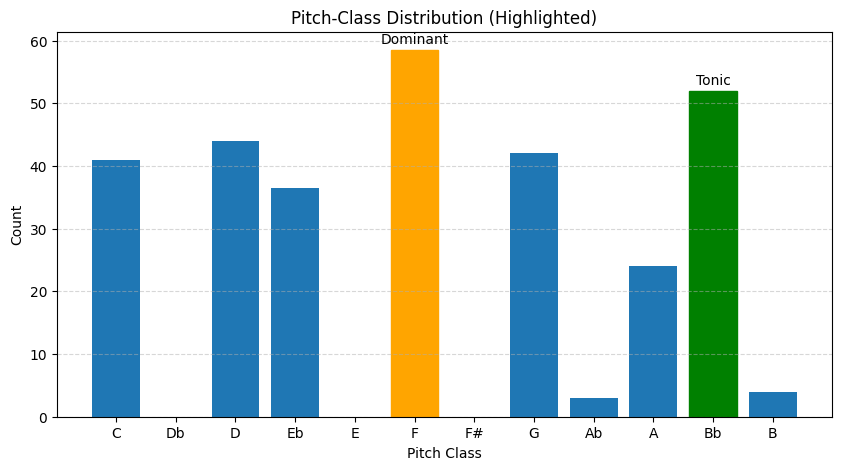

In [35]:
import matplotlib.pyplot as plt
import numpy as np

vec = build_pc_vector_from_midi(df_notes)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(PC_NAMES_FLAT, vec)

max_idx = np.argmax(vec)
bars[max_idx].set_color('red')

tonic = NOTE_TO_PC['Bb']   
dominant = (tonic + 7) % 12  

bars[tonic].set_color('green')
bars[dominant].set_color('orange')

ax.text(tonic, vec[tonic] + 1, "Tonic", ha='center')
ax.text(dominant, vec[dominant] + 1, "Dominant", ha='center')

ax.set_title("Pitch-Class Distribution (Highlighted)")
ax.set_xlabel("Pitch Class")
ax.set_ylabel("Count")

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

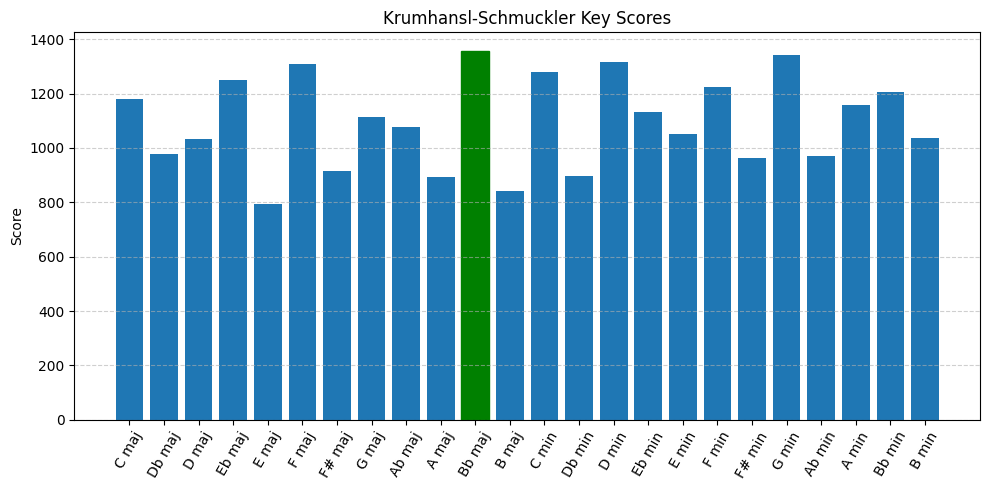

Best match and score: Bb maj 1357.13


In [36]:
import matplotlib.pyplot as plt
import numpy as np

vec = build_pc_vector_from_midi(df_notes)

major_scores = convolute_distribution(vec, 'major')
minor_scores = convolute_distribution(vec, 'minor')

labels = [f"{n} maj" for n in PC_NAMES_FLAT] + [f"{n} min" for n in PC_NAMES_FLAT]
scores = major_scores + minor_scores

best_idx = int(np.argmax(scores))

plt.figure(figsize=(10, 5))
bars = plt.bar(range(len(scores)), scores)

bars[best_idx].set_color('green')

plt.xticks(range(len(scores)), labels, rotation=60)
plt.ylabel("Score")
plt.title("Krumhansl-Schmuckler Key Scores")

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("Best match and score:", labels[best_idx], scores[best_idx])

### Saving the MIDI File

In [37]:
pm = pretty_midi.PrettyMIDI()
instrument = pretty_midi.Instrument(program=0)

step_duration = 0.25
current_chord = tuple(int(x) for x in df_notes.iloc[0])
start_idx = 0

for i in range(1, len(df_notes)):
    chord = tuple(int(x) for x in df_notes.iloc[i])

    if chord != current_chord:
        start_time = start_idx * step_duration
        end_time = i * step_duration

        for pitch in current_chord:
            note = pretty_midi.Note(
                velocity=90,
                pitch=pitch,
                start=start_time,
                end=end_time
            )
            instrument.notes.append(note)

        current_chord = chord
        start_idx = i

start_time = start_idx * step_duration
end_time = len(df_notes) * step_duration

for pitch in current_chord:
    note = pretty_midi.Note(
        velocity=90,
        pitch=pitch,
        start=start_time,
        end=end_time
    )
    instrument.notes.append(note)

pm.instruments.append(instrument)

output_path = "chorale_bach_piano.mid"
pm.write(output_path)

print(f"\nSaved MIDI: {output_path}")


Saved MIDI: chorale_bach_piano.mid


#### Train Test Validation Split

In [38]:
train_files = sorted(Path("jsb_chorales/train").glob("*.csv"))
test_files = sorted(Path("jsb_chorales/test").glob("*.csv"))
valid_files = sorted(Path("jsb_chorales/valid").glob("*.csv"))

In [39]:
train_data = [pd.read_csv(f).values.tolist() for f in train_files]
test_data = [pd.read_csv(f).values.tolist() for f in test_files]
valid_data = [pd.read_csv(f).values.tolist() for f in valid_files]

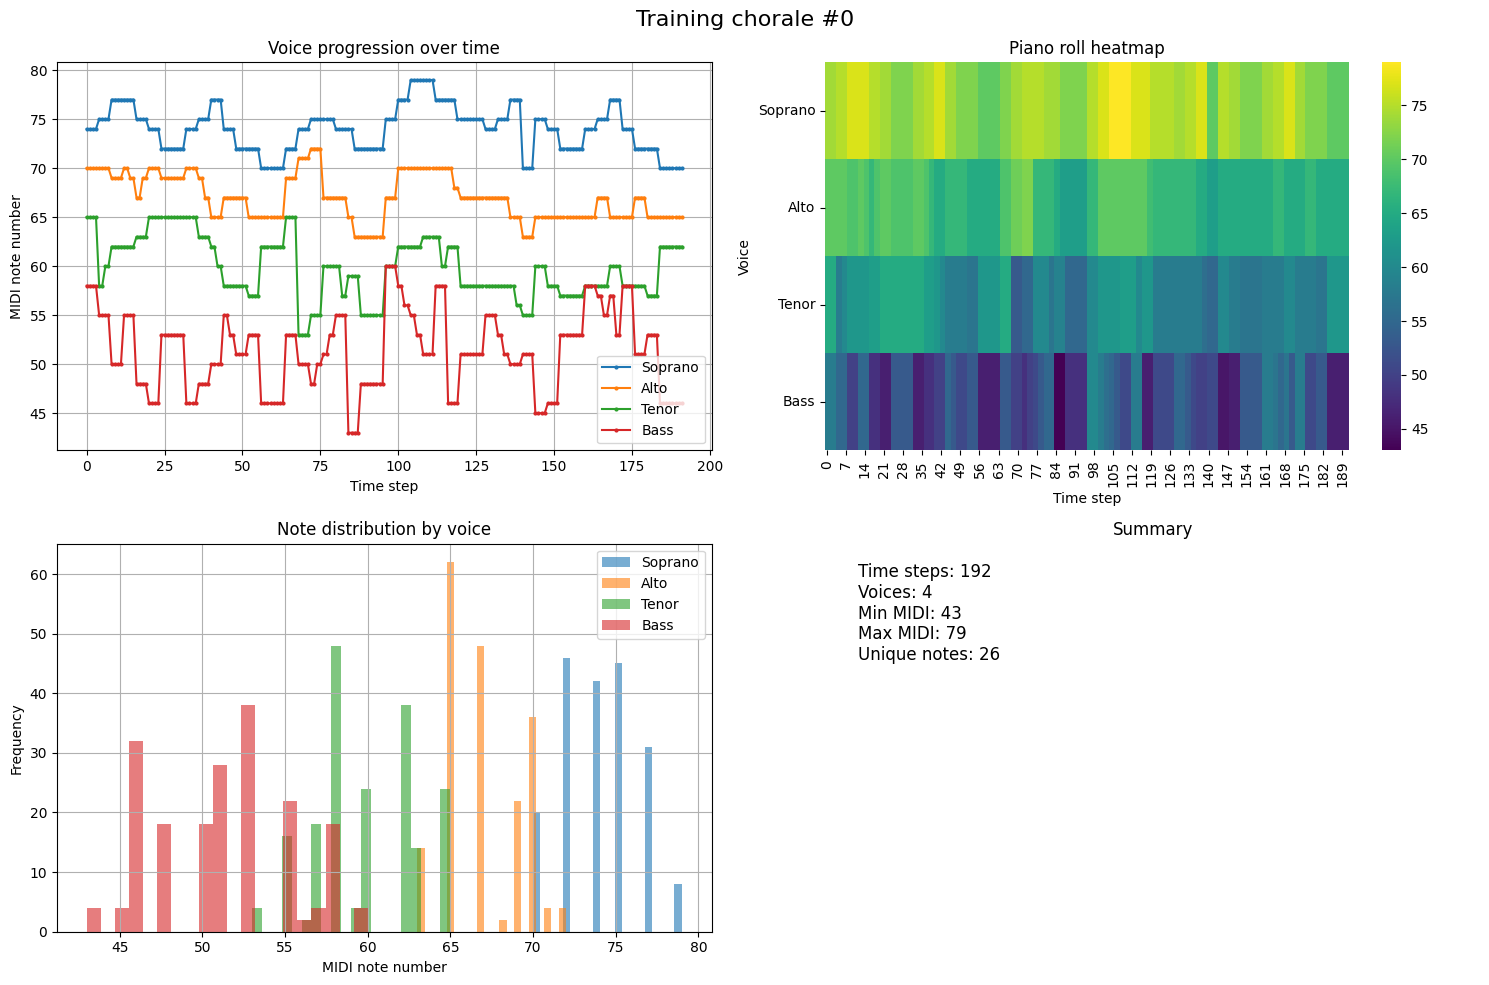

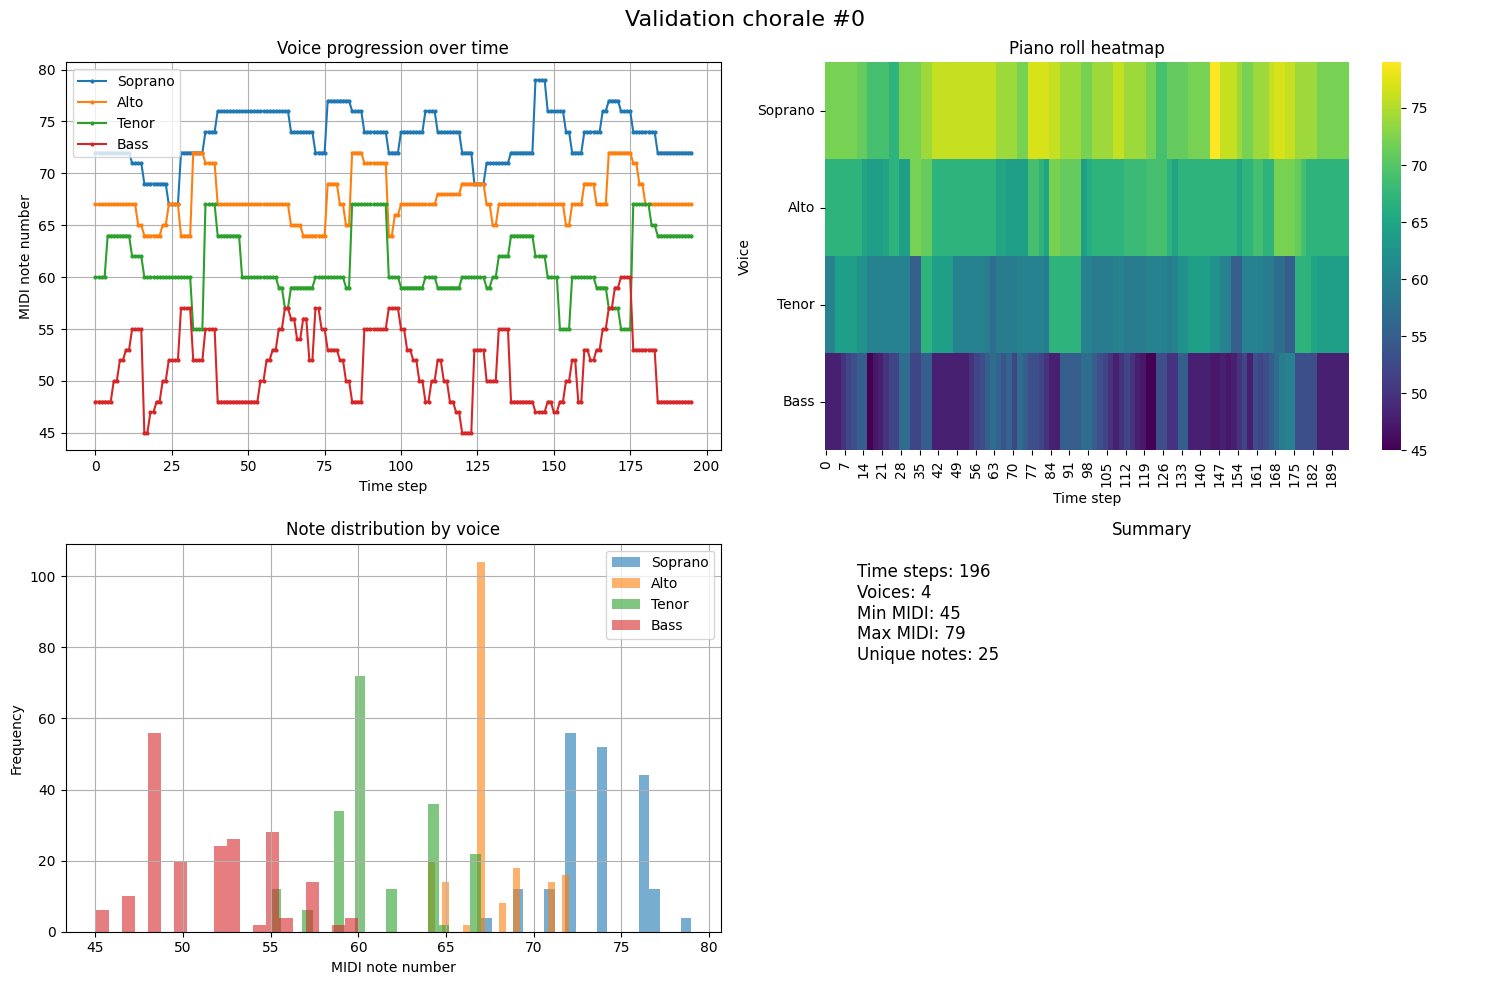

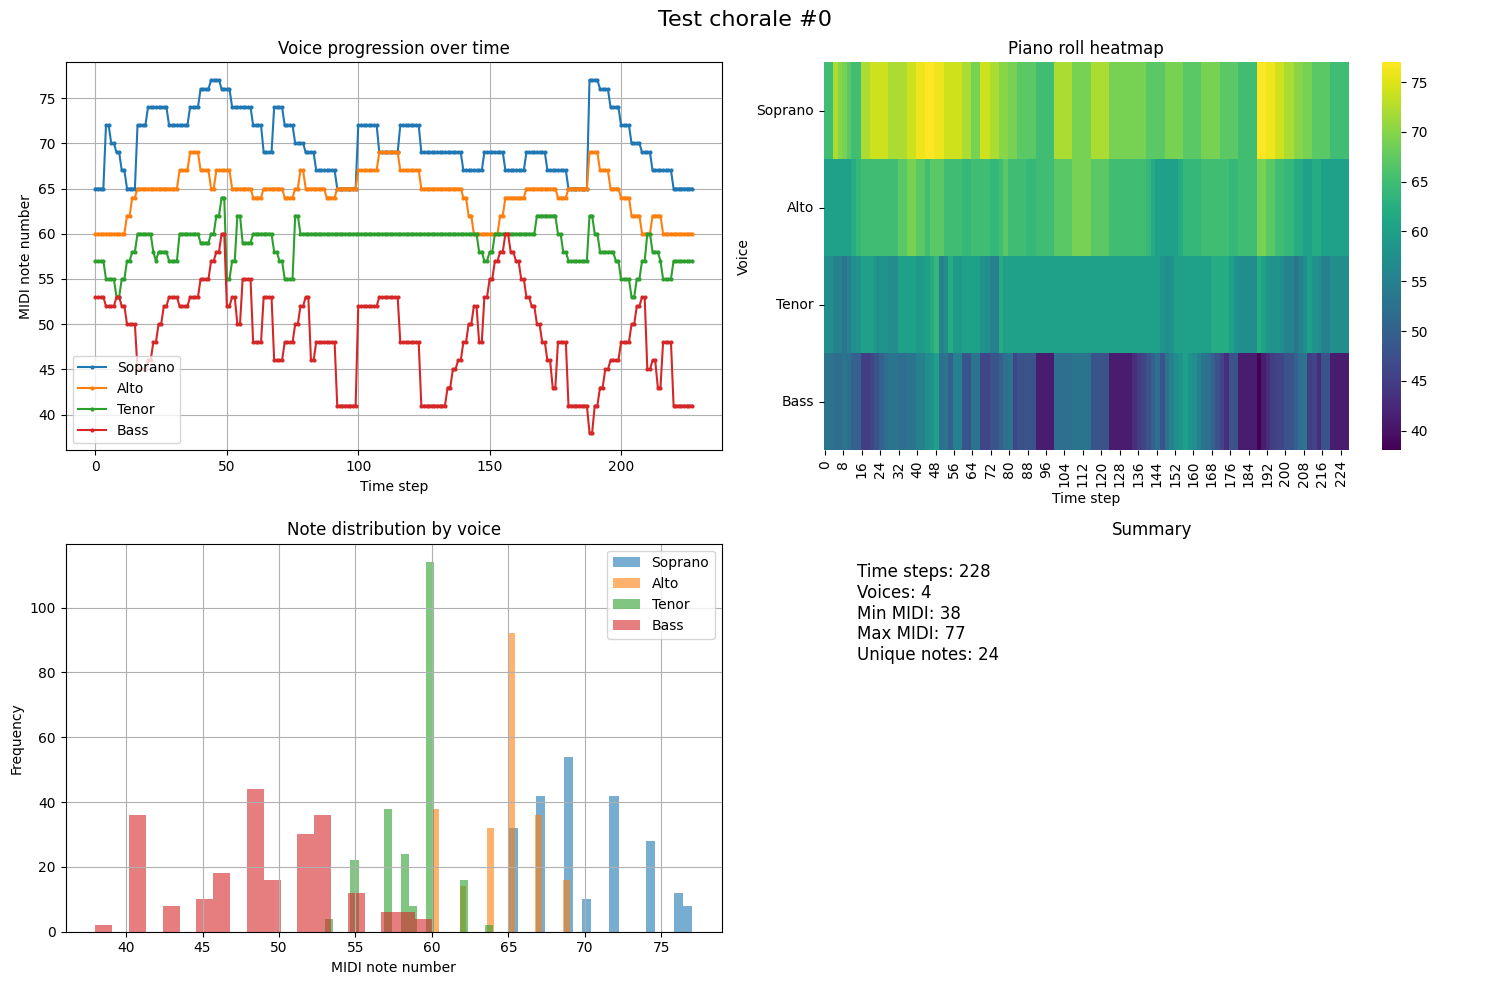

In [40]:
def visualize_chorale(chorale_data, title="Chorale visualization"):
    chorale_array = np.array(chorale_data)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(title, fontsize=16)

    voice_names = ["Soprano", "Alto", "Tenor", "Bass"]
    time_steps = np.arange(len(chorale_array))

    ax = axes[0, 0]
    ax.set_title("Voice progression over time")

    for voice_index in range(4):
        ax.plot(
            time_steps,
            chorale_array[:, voice_index],
            label=voice_names[voice_index],
            marker="o",
            markersize=2
        )

    ax.set_xlabel("Time step")
    ax.set_ylabel("MIDI note number")
    ax.legend()
    ax.grid(True)

    ax = axes[0, 1]
    ax.set_title("Piano roll heatmap")

    sns.heatmap(
        chorale_array.T,
        cmap="viridis",
        ax=ax,
        cbar=True
    )

    ax.set_xlabel("Time step")
    ax.set_ylabel("Voice")
    ax.set_yticks(np.arange(4) + 0.5)
    ax.set_yticklabels(voice_names, rotation=0)

    ax = axes[1, 0]
    ax.set_title("Note distribution by voice")

    for voice_index in range(4):
        voice_notes = chorale_array[:, voice_index]
        voice_notes = voice_notes[voice_notes > 0]
        ax.hist(
            voice_notes,
            bins=20,
            alpha=0.6,
            label=voice_names[voice_index]
        )

    ax.set_xlabel("MIDI note number")
    ax.set_ylabel("Frequency")
    ax.legend()
    ax.grid(True)

    ax = axes[1, 1]
    ax.set_title("Summary")
    ax.axis("off")

    summary_text = (
        f"Time steps: {chorale_array.shape[0]}\n"
        f"Voices: {chorale_array.shape[1]}\n"
        f"Min MIDI: {int(np.min(chorale_array))}\n"
        f"Max MIDI: {int(np.max(chorale_array))}\n"
        f"Unique notes: {len(np.unique(chorale_array))}"
    )
    ax.text(0.05, 0.95, summary_text, va="top", fontsize=12)

    plt.tight_layout()
    plt.show()

visualize_chorale(train_data[0], "Training chorale #0")
visualize_chorale(valid_data[0], "Validation chorale #0")
visualize_chorale(test_data[0], "Test chorale #0")

#### Preprocessing

In [41]:
import numpy as np

min_note = 36
max_note = 81
window_size = 32
window_offset = 16
num_voices = 4

def create_windows(chorales, window_size=32, window_offset=16):
    windows = []

    for chorale in chorales:
        chorale = np.asarray(chorale, dtype=int)

        if len(chorale) < window_size + 1:
            continue

        for start_idx in range(0, len(chorale) - window_size, window_offset):
            window = chorale[start_idx : start_idx + window_size + 1]
            windows.append(window)

    return np.array(windows, dtype=int)


def normalize_notes(data, min_note=36, max_note=81):
    normalized = np.where(data == 0, 0, data - min_note + 1)
    normalized = np.clip(normalized, 0, max_note - min_note + 1)
    return normalized.astype(int)


def flatten_windows(data):
    return data.reshape(data.shape[0], -1)


def split_xy(flattened):
    X = flattened[:, :-num_voices]
    Y = flattened[:, num_voices:]
    return X.astype(int), Y.astype(int)

# Pipeline : chorales - windows - normalize - flatten - split x/y
def make_xy(chorales, window_size=32, window_offset=16, min_note=36, max_note=81):
    windows = create_windows(
        chorales,
        window_size=window_size,
        window_offset=window_offset
    )

    print("Total windows:", len(windows))

    normalized = normalize_notes(
        windows,
        min_note=min_note,
        max_note=max_note
    )

    flattened = flatten_windows(normalized)
    X, Y = split_xy(flattened)

    print("X shape:", X.shape)
    print("Y shape:", Y.shape)

    return X, Y

In [42]:
X_train, Y_train = make_xy(train_data, window_size=32, window_offset=16, min_note=36, max_note=81)
print("-------------")
X_valid, Y_valid = make_xy(valid_data, window_size=32, window_offset=16, min_note=36, max_note=81)
print("-------------")
X_test, Y_test = make_xy(test_data, window_size=32, window_offset=16, min_note=36, max_note=81)

Total windows: 3111
X shape: (3111, 128)
Y shape: (3111, 128)
-------------
Total windows: 1039
X shape: (1039, 128)
Y shape: (1039, 128)
-------------
Total windows: 1067
X shape: (1067, 128)
Y shape: (1067, 128)


### Training The Model

In [43]:
import torch
import torch.nn as nn

class BachLSTM(nn.Module):
    def __init__(self, vocab_size=128, embed_dim=32, hidden_size=256, num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        # 4 notes * embed_dim = LSTM input
        self.lstm = nn.LSTM(
            input_size=4 * embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True           
        )
        
        self.dropout = nn.Dropout(dropout)
    
        self.fc = nn.Linear(hidden_size, 4 * vocab_size)
        
        self.vocab_size = vocab_size

    def forward(self, x, hidden=None):
        batch, seq_len, _ = x.shape
        
        embedded = self.embedding(x)
        
        embedded = embedded.view(batch, seq_len, -1)
        
        out, hidden = self.lstm(embedded, hidden)  
        
        out = self.dropout(out)
        
        last = out[:, -1, :] 
        
        logits = self.fc(last)  
        
        logits = logits.view(batch, 4, self.vocab_size) 
        
        return logits, hidden

Best model saved
Epoch  1/15 | Train Loss: 3.0456  Acc: 13.58% | Val Loss: 2.6404  Acc: 14.85%
Best model saved
Epoch  2/15 | Train Loss: 2.6299  Acc: 14.34% | Val Loss: 2.5975  Acc: 18.17%
Best model saved
Epoch  3/15 | Train Loss: 2.5189  Acc: 18.72% | Val Loss: 2.4420  Acc: 22.59%
Best model saved
Epoch  4/15 | Train Loss: 2.3557  Acc: 23.16% | Val Loss: 2.3304  Acc: 24.18%
Best model saved
Epoch  5/15 | Train Loss: 2.2617  Acc: 25.28% | Val Loss: 2.2529  Acc: 26.08%
Best model saved
Epoch  6/15 | Train Loss: 2.1860  Acc: 27.57% | Val Loss: 2.1952  Acc: 26.76%
Best model saved
Epoch  7/15 | Train Loss: 2.1132  Acc: 30.89% | Val Loss: 2.1416  Acc: 29.69%
Best model saved
Epoch  8/15 | Train Loss: 2.0411  Acc: 32.75% | Val Loss: 2.1028  Acc: 31.42%
Best model saved
Epoch  9/15 | Train Loss: 1.9948  Acc: 34.72% | Val Loss: 2.0763  Acc: 32.72%
Best model saved
Epoch 10/15 | Train Loss: 1.9428  Acc: 36.67% | Val Loss: 2.0570  Acc: 33.35%
Best model saved
Epoch 11/15 | Train Loss: 1.8907 

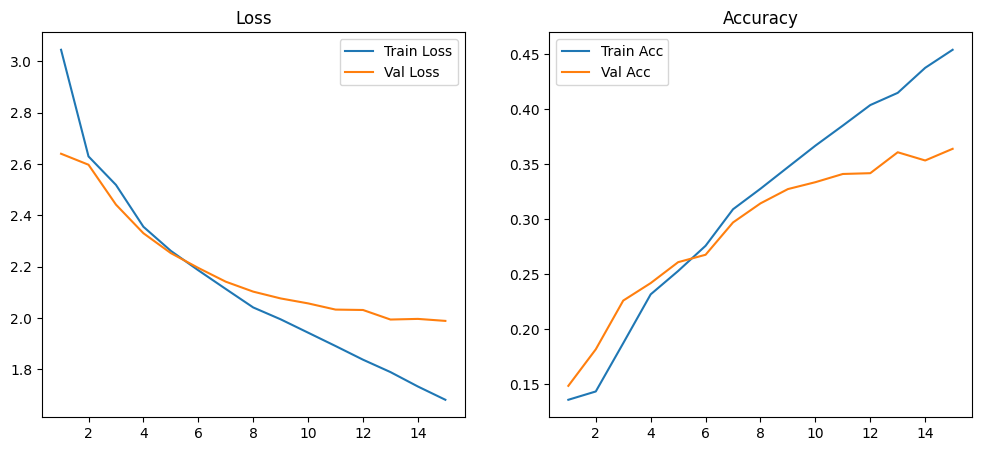

In [44]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

def compute_loss(logits, targets, criterion):
    loss = 0
    for i in range(4):
        loss += criterion(logits[:, i, :], targets[:, i])
    return loss / 4

def plot_training_history(history):
    epochs = range(1, len(history['train_losses']) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_losses'], label='Train Loss')
    plt.plot(epochs, history['val_losses'], label='Val Loss')
    plt.legend()
    plt.title("Loss")

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_accuracies'], label='Train Acc')
    plt.plot(epochs, history['val_accuracies'], label='Val Acc')
    plt.legend()
    plt.title("Accuracy")

    plt.show()

X_train_t = torch.tensor(X_train, dtype=torch.long).view(-1, 32, 4)
Y_train_t  = torch.tensor(Y_train, dtype=torch.long).view(-1, 32, 4)[:, -1, :]
train_loader = DataLoader(TensorDataset(X_train_t, Y_train_t), batch_size=64, shuffle=True)

X_valid_t = torch.tensor(X_valid, dtype=torch.long).view(-1, 32, 4)
Y_valid_t  = torch.tensor(Y_valid, dtype=torch.long).view(-1, 32, 4)[:, -1, :]
val_loader = DataLoader(TensorDataset(X_valid_t, Y_valid_t), batch_size=64, shuffle=False)

model     = BachLSTM().to("cpu")
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

training_history = {
    'train_losses': [], 'val_losses': [],
    'train_accuracies': [], 'val_accuracies': []
}

epochs = 15

best_val_acc = 0

for epoch in range(epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X_batch, Y_batch in train_loader:
        X_batch, Y_batch = X_batch.to("cpu"), Y_batch.to("cpu")
        optimizer.zero_grad()
        logits, _ = model(X_batch)
        loss = compute_loss(logits, Y_batch, criterion)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        preds    = logits.argmax(dim=-1)
        correct += (preds == Y_batch).float().mean(dim=1).sum().item()
        total   += X_batch.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc  = correct / total

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for X_batch, Y_batch in val_loader:
            X_batch, Y_batch = X_batch.to("cpu"), Y_batch.to("cpu")
            logits, _ = model(X_batch)
            val_loss    += compute_loss(logits, Y_batch, criterion).item()
            preds        = logits.argmax(dim=-1)
            val_correct += (preds == Y_batch).float().mean(dim=1).sum().item()
            val_total   += X_batch.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc  = val_correct / val_total

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print("Best model saved")

    training_history['train_losses'].append(train_loss)
    training_history['val_losses'].append(val_loss)
    training_history['train_accuracies'].append(train_acc)
    training_history['val_accuracies'].append(val_acc)

    print(f"Epoch {epoch+1:>2}/{epochs} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.2%} | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.2%}")

plot_training_history(training_history)

In [45]:
device = "cpu"

def sample_from_distribution(probabilities, temperature=1.0):
    probs = np.asarray(probabilities).astype(np.float64)
    if temperature <= 0:
        return int(np.argmax(probs))
    probs = np.log(probs + 1e-9) / temperature
    probs = np.exp(probs)
    probs = probs / np.sum(probs)
    return np.random.choice(len(probs), p=probs)

In [46]:
import torch.nn.functional as F
from IPython.display import Audio, display

def top_p_sampling(probs, p=0.9):
    probs = np.asarray(probs, dtype=np.float64)
    probs = probs / np.sum(probs)
    sorted_idx = np.argsort(probs)[::-1]
    sorted_probs = probs[sorted_idx]
    cumulative = np.cumsum(sorted_probs)
    cutoff = np.where(cumulative > p)[0][0]
    selected_idx = sorted_idx[:cutoff + 1]
    selected_probs = probs[selected_idx]
    selected_probs = selected_probs / np.sum(selected_probs)
    return np.random.choice(selected_idx, p=selected_probs)

def sample_with_temperature(probs, temperature=1.0, p=0.9):
    probs = np.asarray(probs, dtype=np.float64)
    if temperature <= 0:
        return int(np.argmax(probs))
    probs = np.log(probs + 1e-9) / temperature
    probs = np.exp(probs)
    probs = probs / np.sum(probs)
    return top_p_sampling(probs, p=p)

def generate_chorale(model, seed_sequence, length=64, temperature=0.7, max_seq_len=32):
    model.eval()
    generated = np.array(seed_sequence, dtype=int)
    if generated.ndim != 2 or generated.shape[1] != 4:
        raise ValueError()
    generated = generated.reshape(1, generated.shape[0], 4)  
    with torch.no_grad():
        for _ in range(length):
            input_seq = generated[:, -max_seq_len:, :]  
            input_tensor = torch.tensor(input_seq, dtype=torch.long).to(device)
            logits, _ = model(input_tensor)

            next_step = []
            for voice in range(4):
                probs = F.softmax(logits[0, voice], dim=-1).cpu().numpy()
                next_note = sample_with_temperature(probs, temperature=temperature, p=0.9)
                next_step.append(next_note)
            next_step = np.array(next_step).reshape(1, 1, 4)
            generated = np.concatenate([generated, next_step], axis=1)
    return generated[0] 

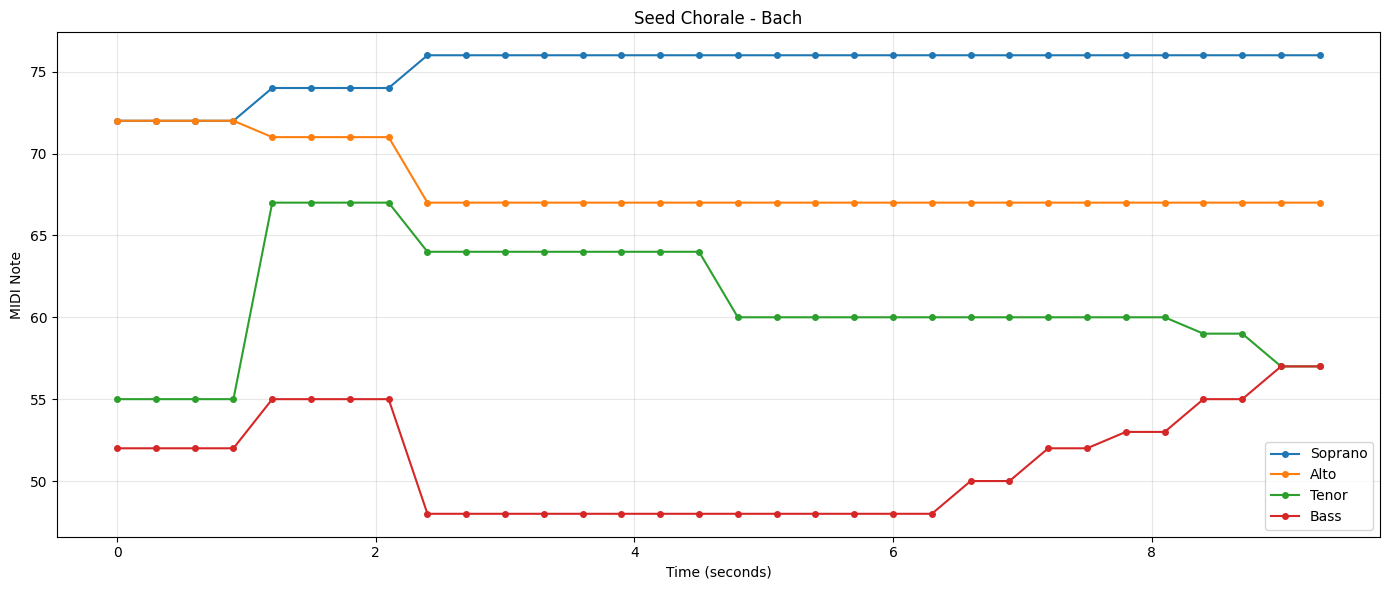

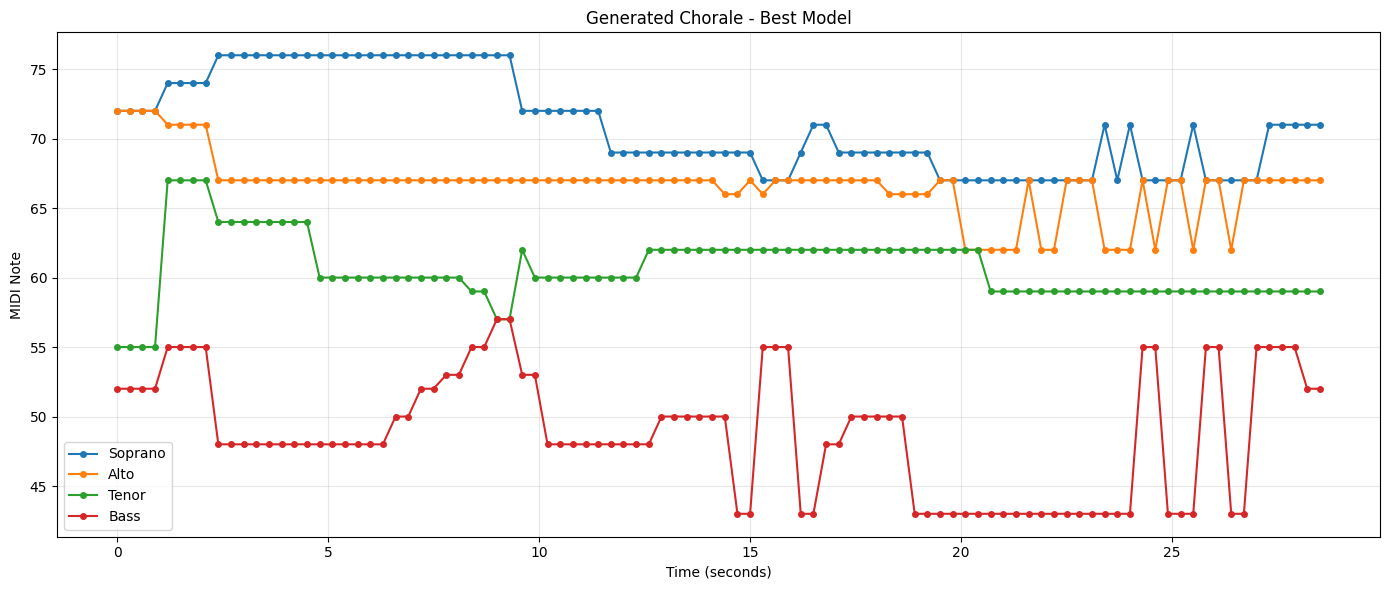

MIDI saved: bach_generated_best_model.mid


In [47]:
from midiutil import MIDIFile

seed = X_valid[2].reshape(32, 4)
generated = generate_chorale(model, seed, length=64, temperature=0.3)

def decode_notes(notes, min_note=36):
    return np.where(notes == 0, 0, notes + min_note - 1)

seed_decoded = decode_notes(seed)
generated_decoded = decode_notes(generated)

def plot_notes(notes_array, title="Chorale", note_duration=0.3):
    voice_names = ["Soprano", "Alto", "Tenor", "Bass"]

    plt.figure(figsize=(14, 6))

    for voice_idx in range(4):
        notes = notes_array[:, voice_idx]
        times = np.arange(len(notes)) * note_duration

        mask = notes > 0
        plt.plot(
            times[mask],
            notes[mask],
            marker='o',
            linewidth=1.5,
            markersize=4,
            label=voice_names[voice_idx]
        )

    plt.title(title)
    plt.xlabel("Time (seconds)")
    plt.ylabel("MIDI Note")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_notes(seed_decoded, "Seed Chorale - Bach", note_duration=0.3)
plot_notes(generated_decoded, "Generated Chorale - Best Model", note_duration=0.3)

def save_midi(notes_array, title="bach_generated", step_duration_sec=0.3, tempo=120):
    voice_names = ["Soprano", "Alto", "Tenor", "Bass"]
    midi_file = MIDIFile(4)

    step_duration_beats = step_duration_sec * tempo / 60.0

    for voice_idx in range(4):
        midi_file.addTrackName(voice_idx, 0, voice_names[voice_idx])
        midi_file.addTempo(voice_idx, 0, tempo)

        notes = notes_array[:, voice_idx]

        merged = []
        i = 0
        while i < len(notes):
            note_num = notes[i]
            duration_beats = step_duration_beats

            while i + 1 < len(notes) and notes[i + 1] == note_num:
                duration_beats += step_duration_beats
                i += 1

            merged.append((note_num, duration_beats))
            i += 1

        time_beats = 0.0
        for note_num, duration_beats in merged:
            if note_num > 0:
                midi_file.addNote(
                    track=voice_idx,
                    channel=voice_idx,
                    pitch=int(note_num),
                    time=time_beats,
                    duration=duration_beats,
                    volume=100
                )
            time_beats += duration_beats

    filename = f"{title}.mid"
    with open(filename, "wb") as f:
        midi_file.writeFile(f)

    print(f"MIDI saved: {filename}")

save_midi(generated_decoded, "bach_generated_best_model", step_duration_sec=0.3, tempo=120)